In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh
from os import environ
%matplotlib inline

I'm studying the dataset.

In [2]:
environ["KAGGLEHUB_ANONYMOUS_DOWNLOAD"]='1'
path=kh.dataset_download("tamber/steam-video-games")
df=pd.read_csv(f"{path}/steam-200k.csv")
df.info(memory_usage='deep')
print(df.shape)
print(df.describe())

100%|██████████| 1.46M/1.46M [00:01<00:00, 1.29MB/s]

Extracting files...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199999 entries, 0 to 199998
Data columns (total 5 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   151603712                   199999 non-null  int64  
 1   The Elder Scrolls V Skyrim  199999 non-null  object 
 2   purchase                    199999 non-null  object 
 3   1.0                         199999 non-null  float64
 4   0                           199999 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 28.1 MB
(199999, 5)
          151603712            1.0         0
count  1.999990e+05  199999.000000  199999.0
mean   1.036556e+08      17.874468       0.0
std    7.208084e+07     138.057292       0.0
min    5.250000e+03       0.100000       0.0
25%    4.738420e+07       1.000000       0.0
50%    8.691201e+07       1.000000       0.0
75%    1.542309e+08       1.300000       0.0
max    3.099031e+08   11754.000000       0.0


I’m reviewing the first five rows of the dataset. I’m learning information about the strange column "0".

In [3]:
display(df.head())
display(df['0'].nunique())

,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
0,151603712,The Elder Scrolls V Skyrim,play,273.0,0
1,151603712,Fallout 4,purchase,1.0,0
2,151603712,Fallout 4,play,87.0,0
3,151603712,Spore,purchase,1.0,0
4,151603712,Spore,play,14.9,0


1

After checking, I performed the first three actions:
1) I deleted the unnecessary column;
2) After checking, it was discovered that the dataset author had forgotten to create columns, which is why the contents of the first row became columns. Then I made the old columns into rows again and created new columns with clear names;
3) I changed the data type of the numeric columns.
After these actions, I reviewed five rows of the modified table.

In [4]:
df1=pd.DataFrame([df.columns.tolist()], columns=df.columns)
df=pd.concat([df, df1], ignore_index=True)
df=df.drop('0', axis=1)
df=df.rename(columns={'151603712': 'user_id', 'The Elder Scrolls V Skyrim': 'game', 'purchase': 'action', '1.0': 'hour'})
df['user_id']=df['user_id'].astype('int32')
df['hour']=df['hour'].astype('float64')
display(df.head())

,user_id,game,action,hour
0,151603712,The Elder Scrolls V Skyrim,play,273.0
1,151603712,Fallout 4,purchase,1.0
2,151603712,Fallout 4,play,87.0
3,151603712,Spore,purchase,1.0
4,151603712,Spore,play,14.9


I am checking the information, the presence of duplicates, and the presence of empty cells in the table.

In [5]:
df.info(memory_usage='deep')
print(df.isna().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  200000 non-null  int32  
 1   game     200000 non-null  object 
 2   action   200000 non-null  object 
 3   hour     200000 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 25.8 MB
user_id    0
game       0
action     0
hour       0
dtype: int64
707


I’m removing complete duplicates. I’m reviewing the information and the table size.

In [6]:
df=df.drop_duplicates()
df.info(memory_usage='deep')
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 199293 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  199293 non-null  int32  
 1   game     199293 non-null  object 
 2   action   199293 non-null  object 
 3   hour     199293 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 27.2 MB
(199293, 4)


I reset the table indices starting from one. I review the fifteen rows of the table, sorted by the number of hours spent playing in descending order.

In [7]:
df.index=np.arange(1, len(df)+1)
display(df.sort_values(by='hour', ascending=False).head(15))

,user_id,game,action,hour
123324,73017395,Sid Meier's Civilization V,play,11754.0
112270,100630947,Dota 2,play,10442.0
186348,153382649,Team Fortress 2,play,9640.0
165022,130882834,Dota 2,play,7765.0
182830,52567955,Dota 2,play,6964.0
128019,121199670,Dota 2,play,6753.0
113062,86256882,Dota 2,play,6015.0
139810,70487610,Sid Meier's Civilization V,play,6013.0
95717,101414179,Dota 2,play,5982.0
140852,12660489,Dota 2,play,5970.0


I’m creating a new table based on grouping by game name and player action type. I’m displaying fifteen rows of the table sorted by the number of users in descending order.

In [8]:
result=df.groupby(['game', 'action'])[['user_id', 'hour']].agg({'user_id': 'count', 'hour': 'sum'})
display(result.sort_values(by='user_id', ascending=False).head(15))

user_id      hour
game                            action                     
Dota 2                          play         4841  981684.6
                                purchase     4841    4841.0
Team Fortress 2                 purchase     2323    2323.0
                                play         2323  173673.3
Unturned                        purchase     1563    1563.0
Counter-Strike Global Offensive purchase     1412    1412.0
                                play         1377  322771.6
Unturned                        play         1069   16096.4
Half-Life 2 Lost Coast          purchase      981     981.0
Counter-Strike Source           purchase      978     978.0
Left 4 Dead 2                   purchase      951     951.0
Counter-Strike                  purchase      856     856.0
Warframe                        purchase      847     847.0
Half-Life 2 Deathmatch          purchase      823     823.0
Left 4 Dead 2                   play          801   33596.7

I’m turning the table into a summary table. As a result, we get a table with the following columns: game name, number of players, and number of buyers.

In [9]:
result['hour']=np.round(result['hour'], 1).astype('float64')
result=result.reset_index()
result=result.pivot(index='game', columns='action', values='user_id').reset_index()
display(result.sort_values(by=['play', 'purchase'], ascending=False).head(15))

action,game,play,purchase
1336,Dota 2,4841.0,4841.0
4257,Team Fortress 2,2323.0,2323.0
981,Counter-Strike Global Offensive,1377.0,1412.0
4788,Unturned,1069.0,1563.0
2475,Left 4 Dead 2,801.0,951.0
984,Counter-Strike Source,715.0,978.0
4364,The Elder Scrolls V Skyrim,677.0,717.0
1894,Garry's Mod,666.0,731.0
978,Counter-Strike,568.0,856.0
3825,Sid Meier's Civilization V,554.0,596.0


Checking the table.

In [10]:
result.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5155 entries, 0 to 5154
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   game      5155 non-null   object 
 1   play      3600 non-null   float64
 2   purchase  5155 non-null   float64
dtypes: float64(2), object(1)
memory usage: 433.4 KB


I’m checking to make sure that the number of players doesn’t exceed the number of buyers for each game.

In [11]:
print(result.loc[result['play']>result['purchase'], :])

action                     game  play  purchase
4632    Tom Clancy's H.A.W.X. 2   8.0       7.0


I’m detecting an anomaly in one game. I’m looking to see where the error might be.

In [12]:
display(df[df['game']=='Tom Clancy\'s H.A.W.X. 2'])

,user_id,game,action,hour
2665,56038151,Tom Clancy's H.A.W.X. 2,purchase,1.0
2666,56038151,Tom Clancy's H.A.W.X. 2,play,0.2
31147,99077905,Tom Clancy's H.A.W.X. 2,purchase,1.0
31148,99077905,Tom Clancy's H.A.W.X. 2,play,8.1
96334,30246419,Tom Clancy's H.A.W.X. 2,purchase,1.0
96335,30246419,Tom Clancy's H.A.W.X. 2,play,2.7
125026,70591968,Tom Clancy's H.A.W.X. 2,purchase,1.0
125027,70591968,Tom Clancy's H.A.W.X. 2,play,1.1
133734,95699780,Tom Clancy's H.A.W.X. 2,purchase,1.0
133735,95699780,Tom Clancy's H.A.W.X. 2,play,3.0


I’m creating a table where duplicates are entered based on the criteria in the first three columns.

In [13]:
result2=df[df.duplicated(subset=['user_id', 'game', 'action'], keep=False)]
display(result2)
result2.info(memory_usage='deep')

,user_id,game,action,hour
15523,118664413,Grand Theft Auto San Andreas,play,1.9
15534,118664413,Grand Theft Auto San Andreas,play,0.2
56780,50769696,Grand Theft Auto San Andreas,play,10.9
56795,50769696,Grand Theft Auto San Andreas,play,3.1
64545,71411882,Grand Theft Auto III,play,1.1
64550,71411882,Grand Theft Auto III,play,0.2
74279,33865373,Sid Meier's Civilization IV,play,135.0
74456,33865373,Sid Meier's Civilization IV,play,2.0
105978,71510748,Grand Theft Auto San Andreas,play,0.6
106023,71510748,Grand Theft Auto San Andreas,play,0.2


<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 15523 to 186126
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  24 non-null     int32  
 1   game     24 non-null     object 
 2   action   24 non-null     object 
 3   hour     24 non-null     float64
dtypes: float64(1), int32(1), object(2)
memory usage: 3.5 KB


It seems that when creating the dataset, 12 rows were unevenly divided into two parts by hour. I create a new table by grouping the first three columns of the main table and aggregating the hours.. After that, I review the modified table and check the difference in the number of rows between the main table and the new table.

In [14]:
result2=df.groupby(['user_id', 'game', 'action'], as_index=False)['hour'].sum()
display(result2)
print(len(df)-len(result2)==12)

,user_id,game,action,hour
0,5250,Alien Swarm,play,4.9
1,5250,Alien Swarm,purchase,1.0
2,5250,Cities Skylines,play,144.0
3,5250,Cities Skylines,purchase,1.0
4,5250,Counter-Strike,purchase,1.0
...,...,...,...,...
199276,309812026,Robocraft,purchase,1.0
199277,309824202,Dota 2,play,0.7
199278,309824202,Dota 2,purchase,1.0
199279,309903146,Dota 2,play,0.2


True


The check confirmed the truth. So I’m creating the main table as a copy from the new table.

In [15]:
df=result2.copy()
display(df.sort_values(by=['hour'], ascending=False).head(15))

,user_id,game,action,hour
84369,73017395,Sid Meier's Civilization V,play,11754.0
111420,100630947,Dota 2,play,10442.0
148292,153382649,Team Fortress 2,play,9640.0
135700,130882834,Dota 2,play,7765.0
57586,52567955,Dota 2,play,6964.0
128395,121199670,Dota 2,play,6753.0
98125,86256882,Dota 2,play,6015.0
81732,70487610,Sid Meier's Civilization V,play,6013.0
112068,101414179,Dota 2,play,5982.0
13485,12660489,Dota 2,play,5970.0


I create a summary table based on the ratio of the number of purchases and games played by each player, using the main table as the basis. I display the result.

In [16]:
result3=df.groupby(['user_id', 'action'])['action'].count()
result3=result3.to_frame(name='count').reset_index()
result3=result3.pivot(index='user_id', columns='action', values='count').reset_index()
display(result3)

action,user_id,play,purchase
0,5250,6.0,21.0
1,76767,20.0,36.0
2,86540,15.0,82.0
3,103360,NaN,10.0
4,144736,1.0,8.0
...,...,...,...
12388,309554670,1.0,1.0
12389,309626088,1.0,1.0
12390,309812026,NaN,2.0
12391,309824202,1.0,1.0


I detect an empty cell. I check the unique number of players and the presence of empty cells in the play column.

In [17]:
print(df['user_id'].nunique())
display(result3[result3['play'].isna()])

12393


action,user_id,play,purchase
3,103360,NaN,10.0
8,299153,NaN,14.0
14,604988,NaN,8.0
20,835015,NaN,8.0
29,1006880,NaN,8.0
...,...,...,...
12340,308327488,NaN,1.0
12360,308851352,NaN,1.0
12365,308925147,NaN,1.0
12385,309375103,NaN,1.0


Once again, I confirm that the number of players does not exceed the number of buyers for each game.

In [18]:
display(result3[result3['play']>result3['purchase']].count())

,0
action,
user_id,0
play,0
purchase,0


I’m checking if there are any more anomalies.

In [19]:
df.info(memory_usage='deep')
print(df.isna().sum())
print(df.duplicated().sum())
print(df.duplicated(subset=['user_id', 'game', 'action']).sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199281 entries, 0 to 199280
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  199281 non-null  int32  
 1   game     199281 non-null  object 
 2   action   199281 non-null  object 
 3   hour     199281 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 25.7 MB
user_id    0
game       0
action     0
hour       0
dtype: int64
0
0


There are no anomalies in the table anymore. I have completely cleaned the dirty data from the dataset. Besides, there were no torrent users.
Now I’m just reviewing the data and doing analyses. Right now, I’m checking the top 20 best‑selling games on Steam.

In [20]:
count_games=df[df['action']=='purchase'].groupby('game')['user_id'].count()
count_games=count_games.to_frame(name='count').reset_index()
display(count_games.sort_values(by='count', ascending=False).head(20))

,game,count
1336,Dota 2,4841
4257,Team Fortress 2,2323
4788,Unturned,1563
981,Counter-Strike Global Offensive,1412
2074,Half-Life 2 Lost Coast,981
984,Counter-Strike Source,978
2475,Left 4 Dead 2,951
978,Counter-Strike,856
4899,Warframe,847
2071,Half-Life 2 Deathmatch,823


I’m creating a bar chart analysis of “Top 20 Best‑Selling Games on Steam.”

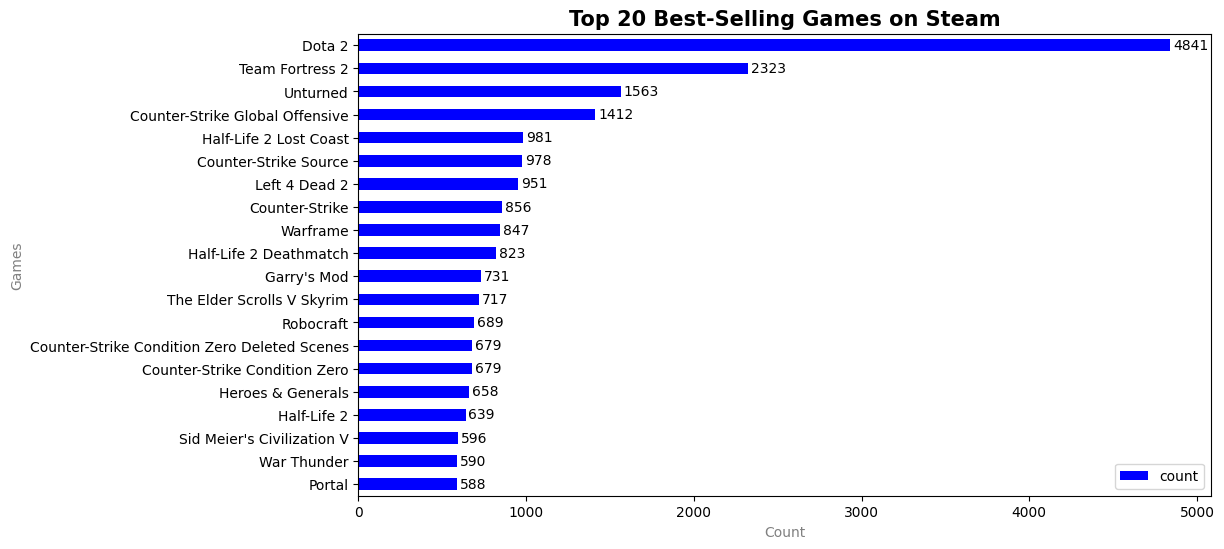

In [21]:
top20=count_games.sort_values(by='count', ascending=False).head(20).iloc[::-1]
ax=top20.plot(kind='barh', x='game', y='count', color='blue', figsize=(11, 6))
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('Top 20 Best‑Selling Games on Steam', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=10, color='grey')
plt.ylabel('Games', fontsize=10, color='grey')
plt.show()

I’m conducting an analysis of the “Top 20 playable games on Steam.”

In [22]:
result4=df[df['action']=='play'].groupby('game')['hour'].sum()
result4=result4.to_frame(name='sum_hour').reset_index()
display(result4.sort_values(by='sum_hour', ascending=False).head(20))

,game,sum_hour
922,Dota 2,981684.6
673,Counter-Strike Global Offensive,322771.6
2994,Team Fortress 2,173673.3
670,Counter-Strike,134261.1
2691,Sid Meier's Civilization V,99821.3
675,Counter-Strike Source,96075.5
3067,The Elder Scrolls V Skyrim,70889.3
1313,Garry's Mod,49725.3
490,Call of Duty Modern Warfare 2 - Multiplayer,42009.9
1733,Left 4 Dead 2,33596.7


I’m creating a bar chart analysis of “The Top 20 Most Playable Games on Steam.”

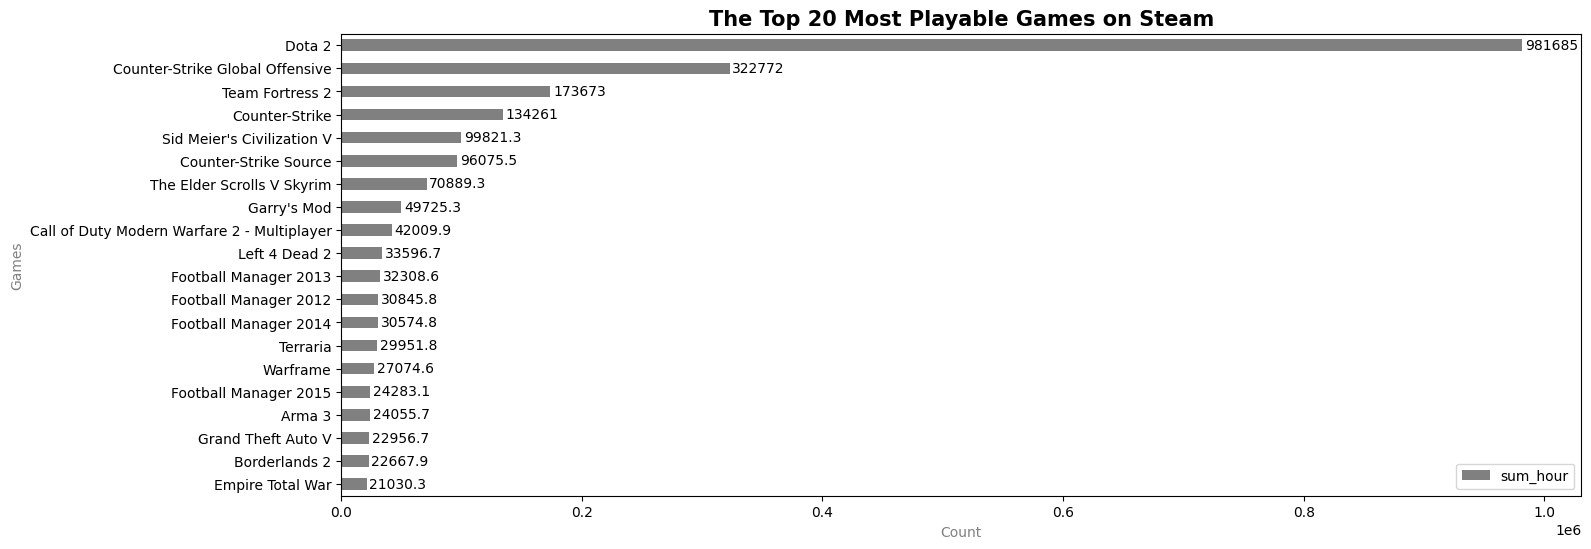

In [23]:
top20_hour=result4.sort_values(by='sum_hour', ascending=False).head(20).iloc[::-1]
ax=top20_hour.plot(kind='barh', x='game', y='sum_hour', color='grey', figsize=(16, 6))
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('The Top 20 Most Playable Games on Steam', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=10, color='grey')
plt.ylabel('Games', fontsize=10, color='grey')
plt.show()

I’m conducting an analysis of the “Top 20 players by the number of games purchased on Steam.”

In [24]:
result5=df[df['action']=='purchase'].groupby('user_id')['game'].count()
result5=result5.to_frame(name='count_games').reset_index()
display(result5.sort_values(by='count_games', ascending=False).head(20))

,user_id,count_games
1729,62990992,1068
784,33865373,776
657,30246419,759
1555,58345543,666
2237,76892907,597
395,20772968,592
211,11403772,588
1796,64787956,584
427,22301321,565
1191,47457723,554


I’m creating a bar chart to analyze the “Top 20 players by the number of games purchased on Steam.”

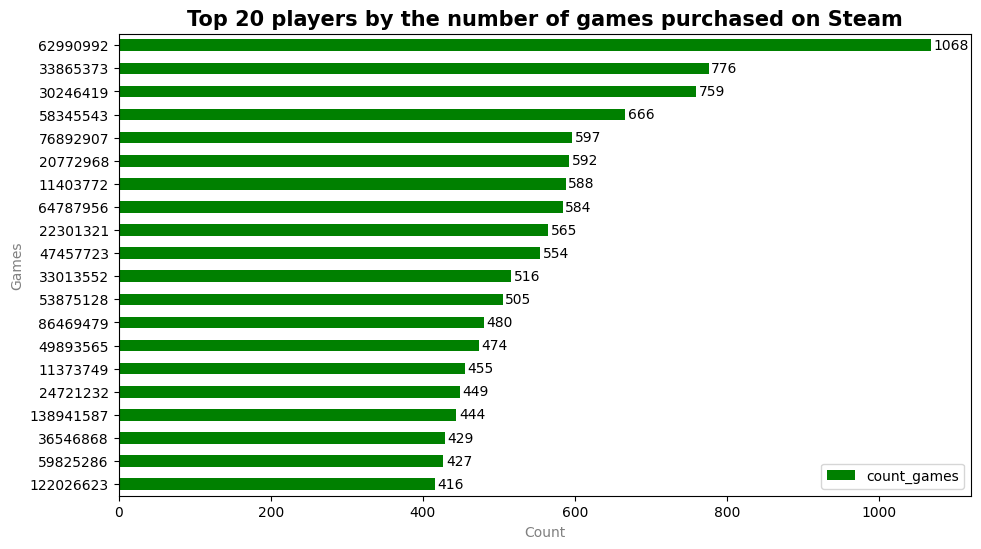

In [25]:
top20_user=result5.sort_values(by='count_games', ascending=False).head(20).iloc[::-1]
ax=top20_user.plot(kind='barh', x='user_id', y='count_games', color='green', figsize=(11, 6))
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('Top 20 players by the number of games purchased on Steam', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=10, color='grey')
plt.ylabel('Games', fontsize=10, color='grey')
plt.show()

I review the number of players, the number of games, and the average number of games per player.

In [26]:
info_steam=pd.Series({
    'count_user': df['game'].nunique(),
    'count_games': df['user_id'].nunique(),
    'average_count_purchases': df.groupby('user_id')['game'].count().mean()
}).astype('int32')
display(info_steam)

,0
count_user,5155
count_games,12393
average_count_purchases,16


Now I’m making a copy of the main table. In the copy, in the column, if the column is equal, I set the value to zero. Then I group by the user_id and game columns and sum up the hours.

In [27]:
result6=df.copy()
result6.loc[df['action']=='purchase', 'hour']=0
result6=result6.groupby(['user_id', 'game'])['hour'].sum()
result6=result6.reset_index()
display(result6.head(10))
display(df[df['user_id']==5250])

,user_id,game,hour
0,5250,Alien Swarm,4.9
1,5250,Cities Skylines,144.0
2,5250,Counter-Strike,0.0
3,5250,Counter-Strike Source,0.0
4,5250,Day of Defeat,0.0
5,5250,Deathmatch Classic,0.0
6,5250,Deus Ex Human Revolution,62.0
7,5250,Dota 2,0.2
8,5250,Half-Life,0.0
9,5250,Half-Life 2,0.0


,user_id,game,action,hour
0,5250,Alien Swarm,play,4.9
1,5250,Alien Swarm,purchase,1.0
2,5250,Cities Skylines,play,144.0
3,5250,Cities Skylines,purchase,1.0
4,5250,Counter-Strike,purchase,1.0
5,5250,Counter-Strike Source,purchase,1.0
6,5250,Day of Defeat,purchase,1.0
7,5250,Deathmatch Classic,purchase,1.0
8,5250,Deus Ex Human Revolution,play,62.0
9,5250,Deus Ex Human Revolution,purchase,1.0


I create a new column in the table copy with a Boolean type, indicating whether the player has ever launched a purchased game. Then I display the information and the size of the table copy.

In [28]:
result6['is_play']=result6['hour']>0
display(result6.head(10))
result6.info(memory_usage='deep')
print(result6.shape)

,user_id,game,hour,is_play
0,5250,Alien Swarm,4.9,True
1,5250,Cities Skylines,144.0,True
2,5250,Counter-Strike,0.0,False
3,5250,Counter-Strike Source,0.0,False
4,5250,Day of Defeat,0.0,False
5,5250,Deathmatch Classic,0.0,False
6,5250,Deus Ex Human Revolution,62.0,True
7,5250,Dota 2,0.2,True
8,5250,Half-Life,0.0,False
9,5250,Half-Life 2,0.0,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128804 entries, 0 to 128803
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  128804 non-null  int32  
 1   game     128804 non-null  object 
 2   hour     128804 non-null  float64
 3   is_play  128804 non-null  bool   
dtypes: bool(1), float64(1), int32(1), object(1)
memory usage: 10.0 MB
(128804, 4)


I am checking that the difference between the number of rows in the main table and its modified copy is equal to the number of rows in the main table where the action column equals “play”.

In [29]:
count_play=df[df['action']=='play'].count()
print(df['user_id'].count()-result6['user_id'].count()==count_play)

user_id    True
game       True
action     True
hour       True
dtype: bool


The check confirmed the truth. So I’m creating the main table as a copy from the new table.

In [30]:
df=result6.copy()
display(df.head(20))
df.info(memory_usage='deep')

,user_id,game,hour,is_play
0,5250,Alien Swarm,4.9,True
1,5250,Cities Skylines,144.0,True
2,5250,Counter-Strike,0.0,False
3,5250,Counter-Strike Source,0.0,False
4,5250,Day of Defeat,0.0,False
5,5250,Deathmatch Classic,0.0,False
6,5250,Deus Ex Human Revolution,62.0,True
7,5250,Dota 2,0.2,True
8,5250,Half-Life,0.0,False
9,5250,Half-Life 2,0.0,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128804 entries, 0 to 128803
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  128804 non-null  int32  
 1   game     128804 non-null  object 
 2   hour     128804 non-null  float64
 3   is_play  128804 non-null  bool   
dtypes: bool(1), float64(1), int32(1), object(1)
memory usage: 10.0 MB


Saving the data in a csv file.

In [31]:
df.to_csv('steam_analysis.csv', index=False)